## Data Preparataion

In [3]:
import numpy as np
from scipy.ndimage import label
!pip install scikit-learn
!pip install kaggle
API_TOKEN="KGAT_2b61c190bcf7bd43aab032d46f704e8c"

In [4]:
import seaborn as sns
import pandas as pd

titanic = sns.load_dataset("titanic")
titanic.info()
titanic.head()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
# Preprocess the data
# Handle missing values
titanic['age'] = titanic['age'].fillna(titanic['age'].median(), inplace=True)
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode(), inplace=True)
titanic.dropna(subset=['embark_town'], inplace=True)


/var/folders/21/1qnyw25s5glfvm0w1zxnzz500000gn/T/ipykernel_56932/3753987654.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic['age'] = titanic['age'].fillna(titanic['age'].median(), inplace=True)
/var/folders/21/1qnyw25s5glfvm0w1zxnzz500000gn/T/ipykernel_56932/3753987654.py:4: ChainedAssignmentError: A value is being set on

In [6]:
# Data type conversion
titanic['sex'] = titanic['sex'].astype('category')
titanic['embarked'] = titanic['embarked'].astype('category')
titanic['class'] = titanic['class'].astype('category')
titanic['who'] = titanic['who'].astype('category')
titanic['alive'] = titanic['alive'].astype('bool')
titanic['alone'] = titanic['alone'].astype('bool')

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,True,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,True,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,True,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,True,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,True,True


In [7]:
duplicates = titanic.duplicated().sum()
if duplicates > 0:
    titanic = titanic.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows")


Removed 110 duplicate rows


In [9]:
# Treat outliers - calculating IQR for age and fare:
Q1 = titanic['fare'].quantile(0.25)
Q3 = titanic['fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
titanic['fare'] = titanic['fare'].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))

Q1 = titanic['age'].quantile(0.25)
Q3 = titanic['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
titanic['age'] = titanic['age'].apply(lambda x: upper_bound if x > upper_bound else (lower_bound if x < lower_bound else x))

titanic['Family_Size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['Is_Alone'] = (titanic['Family_Size'] == 1).astype(int)

titanic['Fare_Per_Person'] = titanic['fare'] / titanic['Family_Size']

#one hot encoding
df = pd.get_dummies(titanic, columns=['sex', 'embarked', 'class', 'who'], drop_first=True)
print("First few rows of the dataset:")
df.head()


First few rows of the dataset:


,survived,pclass,age,sibsp,parch,fare,adult_male,deck,embark_town,alive,...,Family_Size,Is_Alone,Fare_Per_Person,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman
0,0,3,22.0,1,0,7.250,True,NaN,Southampton,True,...,2,0,3.625,True,False,True,False,True,True,False
1,1,1,38.0,1,0,71.050,False,C,Cherbourg,True,...,2,0,35.525,False,False,False,False,False,False,True
2,1,3,26.0,0,0,7.925,False,NaN,Southampton,True,...,1,1,7.925,False,False,True,False,True,False,True
3,1,1,35.0,1,0,53.100,False,C,Southampton,True,...,2,0,26.550,False,False,True,False,False,False,True
4,0,3,35.0,0,0,8.050,True,NaN,Southampton,True,...,1,1,8.050,True,False,True,False,True,True,False


In [10]:
# Display the column names to verify the structure of the dataset
print(df.columns)

Index(['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male',
       'deck', 'embark_town', 'alive', 'alone', 'Family_Size', 'Is_Alone',
       'Fare_Per_Person', 'sex_male', 'embarked_Q', 'embarked_S',
       'class_Second', 'class_Third', 'who_man', 'who_woman'],
      dtype='str')


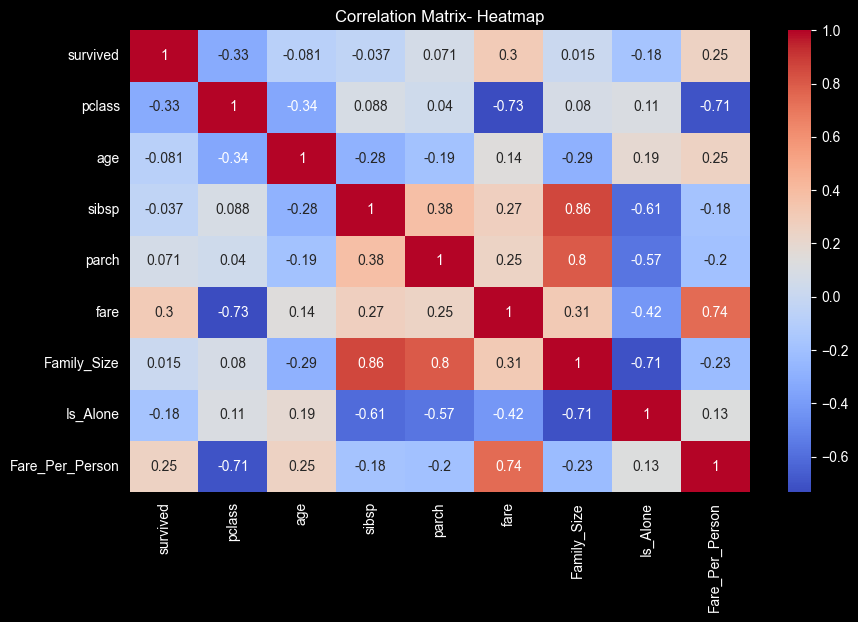

In [12]:
# Find out whether numerical columns are correlated with target value -fare
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
numerical_cols = titanic.select_dtypes(include=[np.number])
sns.heatmap(numerical_cols.corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Matrix- Heatmap')
plt.show()


In [13]:
# Select features and target variable for regression
features = ['pclass', 'age', 'sibsp', 'parch','Family_Size', 'Is_Alone','sex_male', 'embarked_Q', 'embarked_S',
      'class_Second', 'class_Third', 'who_man', 'who_woman','survived']
# Split the data into features (X) and target (y)
X = df[features]
y = df['fare']
X.head()


,pclass,age,sibsp,parch,Family_Size,Is_Alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,survived
0,3,22.0,1,0,2,0,True,False,True,False,True,True,False,0
1,1,38.0,1,0,2,0,False,False,False,False,False,False,True,1
2,3,26.0,0,0,1,1,False,False,True,False,True,False,True,1
3,1,35.0,1,0,2,0,False,False,True,False,False,False,True,1
4,3,35.0,0,0,1,1,True,False,True,False,True,True,False,0


In [16]:
from sklearn.preprocessing import StandardScaler
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled


array([[ 0.88573331, -0.55891076,  0.4795023 , ...,  0.85955761,
        -0.68542784, -0.8371818 ],
       [-1.45717416,  0.66175883,  0.4795023 , ..., -1.16338915,
         1.45894279,  1.19448369],
       [ 0.88573331, -0.25374336, -0.53278034, ..., -1.16338915,
         1.45894279,  1.19448369],
       ...,
       [ 0.88573331, -0.10115966,  0.4795023 , ..., -1.16338915,
         1.45894279, -0.8371818 ],
       [-1.45717416, -0.25374336, -0.53278034, ...,  0.85955761,
        -0.68542784,  1.19448369],
       [ 0.88573331,  0.20400773, -0.53278034, ...,  0.85955761,
        -0.68542784, -0.8371818 ]], shape=(779, 14))

In [17]:
#Split into traiing and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.2, random_state=42)

#Display the first few rows of prepared data
print("Training features:\n", X_train[:5])
print("Training target:\n", y_train[:5])
print("Testing features:\n", X_test[:5])
print("Testing target:\n", y_test[:5])

Training features:
 [[ 0.88573331 -1.62699665  3.51635023  0.69359849  2.66876547 -1.14224942
   0.77221207  3.49333506 -1.6248652  -0.5183914   0.96840639 -1.16338915
  -0.68542784 -0.8371818 ]
 [-0.28572042  0.35659143 -0.53278034 -0.49914593 -0.62178265  0.87546554
   0.77221207 -0.2862594   0.61543567  1.92904435 -1.03262433  0.85955761
  -0.68542784 -0.8371818 ]
 [ 0.88573331 -0.7877863  -0.53278034 -0.49914593 -0.62178265  0.87546554
   0.77221207  3.49333506 -1.6248652  -0.5183914   0.96840639  0.85955761
  -0.68542784 -0.8371818 ]
 [-0.28572042 -0.94037    -0.53278034 -0.49914593 -0.62178265  0.87546554
  -1.29498106 -0.2862594  -1.6248652   1.92904435 -1.03262433 -1.16338915
   1.45894279  1.19448369]
 [-0.28572042 -0.63520261 -0.53278034 -0.49914593 -0.62178265  0.87546554
  -1.29498106 -0.2862594   0.61543567  1.92904435 -1.03262433 -1.16338915
   1.45894279  1.19448369]]
Training target:
 787    29.125
722    13.000
143     6.750
389    12.000
56     10.500
Name: fare, dtyp

In [41]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_error, r2_score, mean_squared_error

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

y_pred


array([0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930979,
       0.40930979, 0.40930979, 0.40930979, 0.40930979, 0.40930

In [44]:
#Evaluate the model
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print("Linear Regression Model Evaluation:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

Linear Regression Model Evaluation:
Mean Absolute Error (MAE): 0.4860476602049636
Mean Squared Error (MSE): 0.24427237415316128
R-squared (R2): -0.0007765147123455218


In [32]:
!pip install statsmodels

RuntimeError: `lowess=True` requires statsmodels, an optional dependency, to be installed.

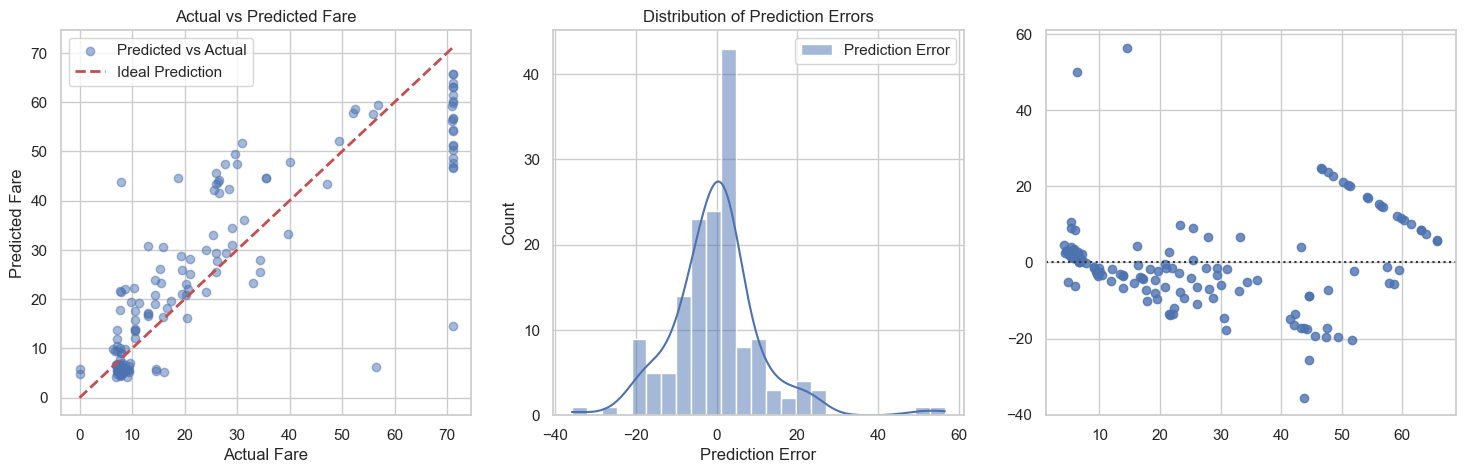

In [33]:
# Visualization of linear regression matrix:

import matplotlib.pyplot as plt

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# Scatter plot of actual vs predicted fares
axes[0].scatter(y_test, y_pred, alpha = 0.5, label="Predicted vs Actual")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2, label = 'Ideal Prediction')
axes[0].set_xlabel('Actual Fare')
axes[0].set_ylabel('Predicted Fare')
axes[0].set_title('Actual vs Predicted Fare')
axes[0].legend()


# Distribution plot of prediction errors
errors = y_test - y_pred
sns.histplot(errors, kde=True, ax=axes[1], label='Prediction Error')
axes[1].set_xlabel('Prediction Error')
axes[1].set_title('Distribution of Prediction Errors')
axes[1].legend()

# Residual plot
sns.residplot(x=y_pred, y=errors, lowess=True, ax=axes[2], label='Residuals')
axes[2].set_xlabel('Predicted Fare')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Residuals vs Predicted Fare')
axes[2].legend()

# Adjust layout
plt.tight_layout()
plt.show()







In [34]:
# Select features and target variable for classification
features = ['pclass', 'age', 'sibsp', 'parch','fare','Fare_Per_Person','Family_Size', 'Is_Alone','sex_male', 'embarked_Q', 'embarked_S',
       'class_Second', 'class_Third', 'who_man', 'who_woman']
target = 'survived'

# Split the data into features (X) and target (y)
X = df[features]
y = df[target]

# Display the first 5 rows of the features data
X.head()

,pclass,age,sibsp,parch,fare,Fare_Per_Person,Family_Size,Is_Alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman
0,3,22.0,1,0,7.250,3.625,2,0,True,False,True,False,True,True,False
1,1,38.0,1,0,71.050,35.525,2,0,False,False,False,False,False,False,True
2,3,26.0,0,0,7.925,7.925,1,1,False,False,True,False,True,False,True
3,1,35.0,1,0,53.100,26.550,2,0,False,False,True,False,False,False,True
4,3,35.0,0,0,8.050,8.050,1,1,True,False,True,False,True,True,False


In [35]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Display the first few rows of the prepared data
print("Training features:\n", X_train[:5])
print("Training target:\n", y_train[:5])
print("Testing features:\n", X_test[:5])
print("Testing target:\n", y_test[:5])

Training features:
 [[ 0.88573331 -1.62699665  3.51635023  0.69359849  0.13677592 -0.73459772
   2.66876547 -1.14224942  0.77221207  3.49333506 -1.6248652  -0.5183914
   0.96840639 -1.16338915 -0.68542784]
 [-0.28572042  0.35659143 -0.53278034 -0.49914593 -0.59327408 -0.20485111
  -0.62178265  0.87546554  0.77221207 -0.2862594   0.61543567  1.92904435
  -1.03262433  0.85955761 -0.68542784]
 [ 0.88573331 -0.7877863  -0.53278034 -0.49914593 -0.87623919 -0.61130631
  -0.62178265  0.87546554  0.77221207  3.49333506 -1.6248652  -0.5183914
   0.96840639  0.85955761 -0.68542784]
 [-0.28572042 -0.94037    -0.53278034 -0.49914593 -0.6385485  -0.26988394
  -0.62178265  0.87546554 -1.29498106 -0.2862594  -1.6248652   1.92904435
  -1.03262433 -1.16338915  1.45894279]
 [-0.28572042 -0.63520261 -0.53278034 -0.49914593 -0.70646013 -0.36743319
  -0.62178265  0.87546554 -1.29498106 -0.2862594   0.61543567  1.92904435
  -1.03262433 -1.16338915  1.45894279]]
Training target:
 787    0
722    0
143    0
3

In [36]:
#Implementation of Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logistic_model = LogisticRegression()
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)
y_pred


array([0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0])

In [38]:
#Model Evaluation - Confusion Matrix:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# Display the evaluation results
print("Accuracy of Logistic Regression model:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy of Logistic Regression model: 0.7884615384615384
Confusion Matrix:
 [[82  8]
 [25 41]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.91      0.83        90
           1       0.84      0.62      0.71        66

    accuracy                           0.79       156
   macro avg       0.80      0.77      0.77       156
weighted avg       0.80      0.79      0.78       156



#### Interpretation of Logistic Regression Results

1. **Accuracy**:
   - The model has an accuracy of approximately 78.8%, meaning it correctly classifies around 79% of the instances.

2. **Confusion Matrix**:
   - The confusion matrix is as follows:
     ```
     [[A  B]
      [ C  D]]
     ```
  - **True Negatives (TN):** `A` passengers who did not survive were correctly predicted as not surviving.
  - **False Positives (FP):** `B` passengers who did not survive were incorrectly predicted as survivors.
  - **False Negatives (FN):** `C` passengers who survived were incorrectly predicted as not surviving.
  - **True Positives (TP):** `D` passengers who survived were correctly predicted as survivors.


3. **Classification Report**:

  The classification report provides detailed metrics to evaluate the performance of the model for each class, which are summarized below:

  - **Class 0 (Not Survived):**
    - **Precision:** 0.77, meaning 77% of passengers predicted as not surviving were correctly classified.
    - **Recall:** 0.91, indicating that the model successfully identified 91% of the actual non-survivors.
    - **F1-Score:** 0.83, which is a balanced measure of precision and recall, showing that the model performs well in predicting passengers who did not survive.

  - **Class 1 (Survived):**
    - **Precision:** 0.84, meaning 84% of passengers predicted as surviving were correctly classified as survivors.
    - **Recall:** 0.62, indicating that the model correctly identified 62% of actual survivors, highlighting some room for improvement in capturing all survivors.
    - **F1-Score:** 0.71, which reflects a moderate balance between precision and recall for predicting survivors, suggesting the model is fairly good but has potential for enhancement in this area.

4. **Macro and Weighted Averages**:
  - **Macro Average:**
  Both classes are treated equally, resulting in a precision, recall, and F1-score of 0.80, 0.77, and 0.77, respectively.
  - **Weighted Average:**
  Takes into account the support (number of true instances) for each class, leading to an F1-score of 0.78, indicating overall model performance.


#### Overall Model Performance:
- The model performs better in predicting non-survivors (Class 0) than survivors (Class 1), with higher recall and F1-score for Class 0. While the precision for predicting survivors is high, the lower recall for Class 1 suggests that the model misses a significant number of actual survivors, indicating an area for potential improvement.

Visualization of Logistic Regression Metrics
These visualizations will provide insights into the strengths and weaknesses of the Logistic Regression model, highlighting areas for potential improvement.

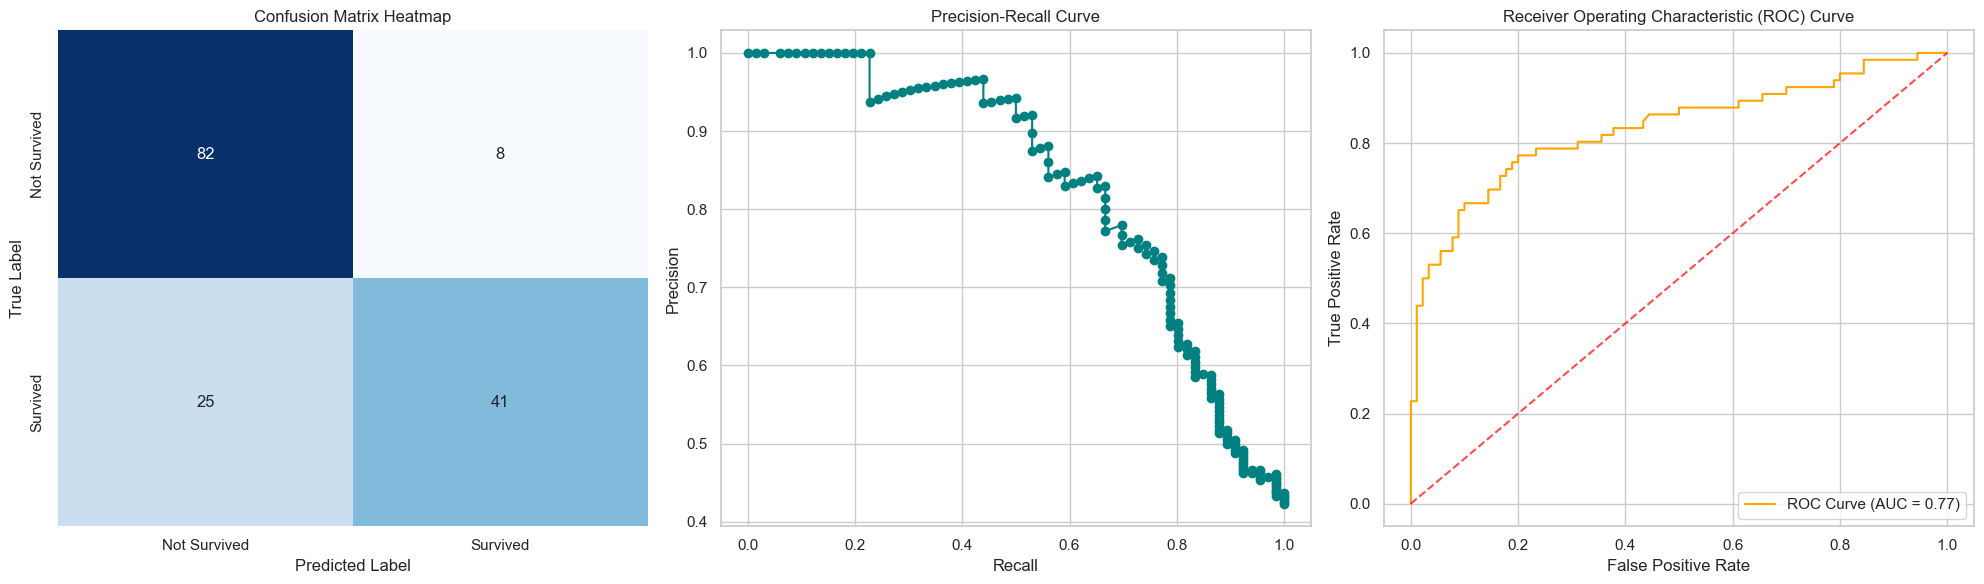

In [39]:
# Make predictions and ensure y_pred is in integer format
y_pred = logistic_model.predict(X_test).astype(int)

# Convert y_test to integers if they are strings (in case this is needed)
y_test = y_test.astype(int)

# Import necessary libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure with a larger size for better readability
plt.figure(figsize=(20, 6))

# 1. Confusion Matrix Heatmap
plt.subplot(1, 3, 1)  # 1 row, 3 columns, first subplot
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'], cbar=False)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# 2. Precision-Recall Curve
plt.subplot(1, 3, 2)  # 1 row, 3 columns, second subplot
precision, recall, _ = precision_recall_curve(y_test, logistic_model.predict_proba(X_test)[:, 1])
plt.plot(recall, precision, marker='o', color='teal')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)

# 3. ROC Curve
plt.subplot(1, 3, 3)  # 1 row, 3 columns, third subplot
fpr, tpr, _ = roc_curve(y_test, logistic_model.predict_proba(X_test)[:, 1])
roc_auc = roc_auc_score(y_test, y_pred)
plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc), color='orange')
plt.plot([0, 1], [0, 1], linestyle='--', color='red', alpha=0.7)
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)

# Adjust layout for better spacing
plt.tight_layout()
plt.show()